<a href="https://colab.research.google.com/github/Lukas98275/Mineria-de-datos/blob/main/Lab01_EDA_Rozas_Lukas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Fases CRISP-DM
##Comprensión del negocio:

En este proyecto buscamos analizar la una base de datos de ONE PIECE que tiene como datos los capitulos del anime y las calificaciones de cada capitulo buscamos analizar cuantos capitulos tiene por año, que año tiene los mejores capitulos, etc.

###Comprensión de los datos:

La base de datos fue seleccionada desde la paguina de Kaggle al analizarla nos podemos fijar de las columnas


Nombre del dataset: [ONE PIECE ANIME]
Autor o publicador: [nombre]
Enlace: [https://www.kaggle.com/datasets/aditya2803/one-piece-anime]
Archivo seleccionado: [ONE PIECE.csv]
Unidad de análisis: cada fila representa [ Columnas : Nombre del episodio, Clasificación del episodio, Clasificación del episodio]
Justificación: elegí esta fuente porque [Elegi esta base de datos porque es de un tema que conozco y me gustaria explorar en sus datos]
Pregunta inicial: me interesa explorar [Los mejores capitulos segun su clasificacion]
Licencia o condiciones de uso: [CC0: Dominio público]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")
print("Librerias cargadas correctamente")


Librerias cargadas correctamente


In [ ]:
from google.colab import files
archivos_subidos = files.upload()
nombre_csv = next(iter(archivos_subidos))
print("Archivo seleccionado:", nombre_csv)

Saving ONE PIECE.csv to ONE PIECE.csv
Archivo seleccionado: ONE PIECE.csv


In [ ]:
df = pd.read_csv(nombre_csv)
print("Dataset cargado correctamente")
df.head()


Dataset cargado correctamente


,Unnamed: 0,rank,trend,season,episode,name,start,total_votes,average_rating
0,0,"24,129",18,1,1,I'm Luffy! The Man Who Will Become the Pirate ...,1999,647,7.60
1,1,"29,290",11,1,2,"The Great Swordsman Appears! Pirate Hunter, Ro...",1999,473,7.80
2,2,"32,043",7,1,3,Morgan vs. Luffy! Who's This Beautiful Young G...,1999,428,7.70
3,3,"28,818",8,1,4,Luffy's Past! The Red-haired Shanks Appears!,1999,449,8.10
4,4,"37,113",4,1,5,"Fear, Mysterious Power! Pirate Clown Captain B...",1999,370,7.50


In [ ]:
filas, columnas = df.shape
print("Cantidad de filas:", filas)
print("Cantidad de columnas:", columnas)

Cantidad de filas: 958
Cantidad de columnas: 9


El dataset contiene 958 filas y 9
columnas. Cada fila representa un capitulo de ONE PIECE, según la documentación de Kaggle

In [ ]:
display(df.head())
display(df.tail())
display(df.sample(n=min(5, len(df)), random_state=42))

,Unnamed: 0,rank,trend,season,episode,name,start,total_votes,average_rating
0,0,"24,129",18,1,1,I'm Luffy! The Man Who Will Become the Pirate ...,1999,647,7.60
1,1,"29,290",11,1,2,"The Great Swordsman Appears! Pirate Hunter, Ro...",1999,473,7.80
2,2,"32,043",7,1,3,Morgan vs. Luffy! Who's This Beautiful Young G...,1999,428,7.70
3,3,"28,818",8,1,4,Luffy's Past! The Red-haired Shanks Appears!,1999,449,8.10
4,4,"37,113",4,1,5,"Fear, Mysterious Power! Pirate Clown Captain B...",1999,370,7.50


,Unnamed: 0,rank,trend,season,episode,name,start,total_votes,average_rating
953,953,"41,448",26,1,954,Its Name is Enma! Oden's Meito!,2020,302,7.70
954,954,"35,342",44,1,955,&quot;A New Alliance?! Kaido's Army Gathers&quot;,2020,407,7.40
955,955,"33,715",75,1,956,Ticking Down to the Great Battle! The Straw Ha...,2020,353,8.20
956,956,"2,940",964,1,957,Big News! The Warlords Attack Incident,2021,"2,862",9.10
957,957,"14,751",-,1,958,&quot;The Legendary Battle! Garp and Roger&quot;,2021,746,9.40


,Unnamed: 0,rank,trend,season,episode,name,start,total_votes,average_rating
836,836,"92,995",2,1,837,The Birth of Mom! The Day That Carmel Vanished!,2018,84,8.10
477,477,"52,767",4,1,478,Yakusoku no Tame ni!! Gekitou! Luffy to Coby,2010,175,8.60
350,350,"76,142",-,1,351,500-nenburi no Mezame!! Oars Kaigan!!,2008,126,7.80
891,891,"29,288",29,1,892,Wano Country! To the Land of Dancing Sakura an...,2019,340,9.20
855,855,"51,718",8,1,856,The Forbidden Secret! Katakuri's Merienda!,2018,168,8.90


En base a este resumen podemos observar que en la columba trend puede no tener algun dato, el nombre de las columnas son claros.


In [ ]:
print("Columnas disponibles:")
for numero, columna in enumerate(df.columns, start=1):
    print(numero, "−", columna)

Columnas disponibles:
1 − Unnamed: 0
2 − rank
3 − trend
4 − season
5 − episode
6 − name
7 − start
8 − total_votes
9 − average_rating


la columna que parece identificar cada registro;
La Columna Unnamed es la que identifica cada regristo.

dos columnas numéricas que tengan significado analítico;
las columnas RANK Y AVERGE_RATING

una columna categórica con grupos comprensibles;
la columna EPISODE

una posible columna de fecha;
la columba START

una columna cuyo significado necesites consultar en Kaggle.
la columna average_rating



In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 958 entries, 0 to 957
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      958 non-null    int64  
 1   rank            958 non-null    object 
 2   trend           958 non-null    object 
 3   season          958 non-null    int64  
 4   episode         958 non-null    int64  
 5   name            958 non-null    object 
 6   start           958 non-null    int64  
 7   total_votes     958 non-null    object 
 8   average_rating  958 non-null    float64
dtypes: float64(1), int64(4), object(4)
memory usage: 67.5+ KB


In [ ]:
resumen_columnas = pd.DataFrame({
"tipo_pandas": df.dtypes.astype(str),
"datos_presentes": df.notna().sum(),
"datos_nulos": df.isna().sum(),
"valores_unicos": df.nunique(dropna=True)
})
resumen_columnas


,tipo_pandas,datos_presentes,datos_nulos,valores_unicos
Unnamed: 0,int64,958,0,958
rank,object,958,0,958
trend,object,958,0,34
season,int64,958,0,1
episode,int64,958,0,958
name,object,958,0,957
start,int64,958,0,23
total_votes,object,958,0,210
average_rating,float64,958,0,39


In [ ]:
columnas_numericas = df.select_dtypes(
include=np.number
).columns.tolist()
columnas_categoricas = df.select_dtypes(
include=["object", "category", "bool"]
).columns.tolist()
print("Columnas numericas:", columnas_numericas)
print("Columnas categoricas:", columnas_categoricas)

Columnas numericas: ['Unnamed: 0', 'season', 'episode', 'start', 'average_rating']
Columnas categoricas: ['rank', 'trend', 'name', 'total_votes']


Columnas Numericas: 5

Columnas Categoricas: 4

la columna start la toman como numerico y es una fecha no se calcula como numero

In [ ]:
resumen_nulos = pd.DataFrame({
"cantidad_nulos": df.isnull().sum(),
"porcentaje_nulos": (df.isnull().mean() *
100).round(2)
})
resumen_nulos = resumen_nulos.sort_values(
by="porcentaje_nulos",
ascending=False
)
resumen_nulos


,cantidad_nulos,porcentaje_nulos
Unnamed: 0,0,0.00
rank,0,0.00
trend,0,0.00
season,0,0.00
episode,0,0.00
name,0,0.00
start,0,0.00
total_votes,0,0.00
average_rating,0,0.00


In [ ]:
columnas_con_nulos = resumen_nulos[
resumen_nulos["cantidad_nulos"] > 0
]
columnas_con_nulos

,cantidad_nulos,porcentaje_nulos


no tengo columnas con valores nulos

In [ ]:
cantidad_duplicados = df.duplicated().sum()
porcentaje_duplicados = cantidad_duplicados / len(df) *100
print("Filas duplicadas:", cantidad_duplicados)
print("Porcentaje duplicado:", round(porcentaje_duplicados, 2), " %")

Filas duplicadas: 0
Porcentaje duplicado: 0.0  %


Sin filas duplicadas


In [ ]:
valores_diferentes = df.nunique(dropna=False).sort_values()
valores_diferentes


,0
season,1
start,23
trend,34
average_rating,39
total_votes,210
name,957
Unnamed: 0,958
rank,958
episode,958


In [ ]:
print(columnas_numericas)

['Unnamed: 0', 'season', 'episode', 'start', 'average_rating']


In [ ]:
if columnas_numericas:
  resumen_numerico = df[columnas_numericas].describe().T
  display(resumen_numerico)
else:
  print("El dataset no tiene columnas numericas detectadas")

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,958.00,478.50,276.70,0.00,239.25,478.50,717.75,957.00
season,958.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00
episode,958.00,479.50,276.70,1.00,240.25,479.50,718.75,958.00
start,958.00,"2,010.23",6.05,"1,999.00","2,005.00","2,010.00","2,015.00","2,021.00"
average_rating,958.00,7.80,0.59,5.60,7.50,7.80,8.20,9.60


In [ ]:
if columnas_numericas:
  comparacion_centro = pd.DataFrame({
  "media": df[columnas_numericas].mean(),
  "mediana": df[columnas_numericas].median(),
  "desviacion_estandar": df[columnas_numericas].std(),
  "minimo": df[columnas_numericas].min(),
  "maximo": df[columnas_numericas].max()
})
display(comparacion_centro)


,media,mediana,desviacion_estandar,minimo,maximo
Unnamed: 0,478.50,478.50,276.70,0.00,957.00
season,1.00,1.00,0.00,1.00,1.00
episode,479.50,479.50,276.70,1.00,958.00
start,"2,010.23","2,010.00",6.05,"1,999.00","2,021.00"
average_rating,7.80,7.80,0.59,5.60,9.60


In [ ]:
if columnas_numericas:
  tabla_percentiles = df[columnas_numericas].quantile(
[0.00, 0.05, 0.25, 0.50, 0.75, 0.95, 1.00]
).T
tabla_percentiles.columns = [
"min", "p05", "p25", "p50_mediana",
"p75", "p95", "max"
]
display(tabla_percentiles)

,min,p05,p25,p50_mediana,p75,p95,max
Unnamed: 0,0.00,47.85,239.25,478.50,717.75,909.15,957.00
season,1.00,1.00,1.00,1.00,1.00,1.00,1.00
episode,1.00,48.85,240.25,479.50,718.75,910.15,958.00
start,"1,999.00","2,000.00","2,005.00","2,010.00","2,015.00","2,019.00","2,021.00"
average_rating,5.60,6.70,7.50,7.80,8.20,8.71,9.60


Columna "average_rating"
“El 25 % de los registros tiene un valor menor o igual a [7.50]”

“La mediana es [7.80], mientras la media es []”.

Entre el percentil 95 y el máximo existe una diferencia de 0.89, lo que podría indicar la presencia de valores atípicos altos o episodios excepcionalmente bien valorados en el extremo superior de la distribución

In [ ]:
if columnas_categoricas:
  resumen_categorico = df[columnas_categoricas].describe().T
  display(resumen_categorico)
else:
  print("No se detectaron columnas categoricas")


,count,unique,top,freq
rank,958,958,"14,751",1
trend,958,34,-,374
name,958,957,The Cake Sank?! Sanji and Bege's Getaway Battle!,2
total_votes,958,210,118,24


In [ ]:
print(columnas_categoricas)
# Cambia el indice si la primera columna no es adecuada.
columna_categorica = columnas_categoricas[3]
print("Columna elegida:", columna_categorica)


['rank', 'trend', 'name', 'total_votes']
Columna elegida: total_votes


In [ ]:
frecuencia = df[columna_categorica].value_counts(
dropna=False
)
porcentaje = df[columna_categorica].value_counts(
dropna=False,
normalize=True
).mul(100).round(2)
tabla_frecuencias = pd.DataFrame({
"cantidad": frecuencia,
"porcentaje": porcentaje
})
tabla_frecuencias.head(15)


,cantidad,porcentaje
total_votes,,
118,24,2.51
125,23,2.40
124,21,2.19
122,21,2.19
126,20,2.09
115,20,2.09
117,19,1.98
116,19,1.98
121,18,1.88


In [ ]:
print(columnas_numericas)
# Cambia el indice para elegir una variable significativa.
columna_numerica = columnas_numericas[4]
print("Columna elegida:", columna_numerica)


['Unnamed: 0', 'season', 'episode', 'start', 'average_rating']
Columna elegida: average_rating


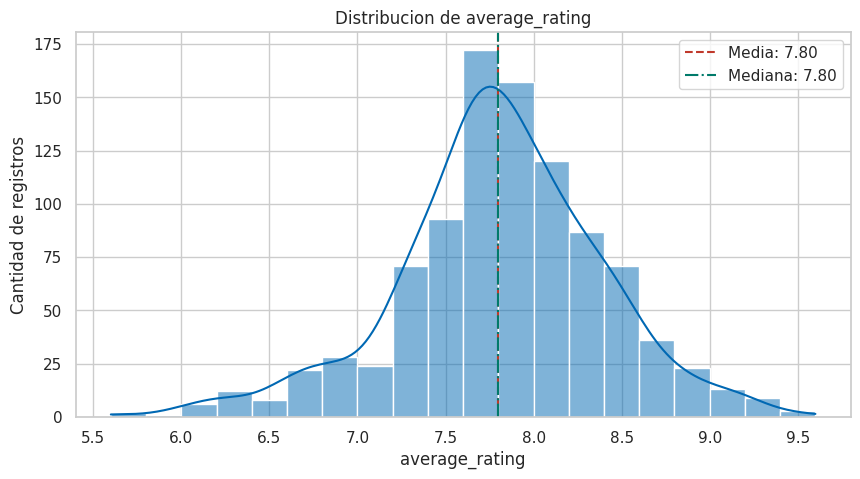

In [ ]:
media = df[columna_numerica].mean()
mediana = df[columna_numerica].median()

plt.figure(figsize=(10, 5))

sns.histplot(
  data=df,
  x=columna_numerica,
  bins=20,
  kde=True,
  color="#0068B3"
)
plt.axvline(
media,
  color="#C0392B",
  linestyle="--",
  label=f"Media: {media:.2f}"
)
plt.axvline(
  mediana,
  color="#007A6A",
  linestyle="-.",
  label=f"Mediana: {mediana:.2f}"
)
plt.title(f"Distribucion de {columna_numerica}")
plt.xlabel(columna_numerica)
plt.ylabel("Cantidad de registros")
plt.legend()

¿Dónde se concentra la mayoría de los valores?
la mayor cantidad de valores se encuentran entre el 7.5 y el 8.0

¿La forma parece aproximadamente simétrica o presenta una cola hacia un extremo?
aproximadamente simetrica.

¿Media y mediana están cercanas?
la media y mediana son identicas ambas tienen un valor de 7.80

¿Existen zonas aisladas o valores muy alejados?
No se observan barras totalmente desconectadas o valores aislados extremos, pero sí hay registros en los bordes con frecuencias muy bajas en el borde izquierdo y muy altas en el borde derecho

¿La forma podría depender de límites naturales o de cómo se midió la variable?
Sí. Al tratarse de un promedio de calificaciones , la variable tiene un límite superior natural de 10.0

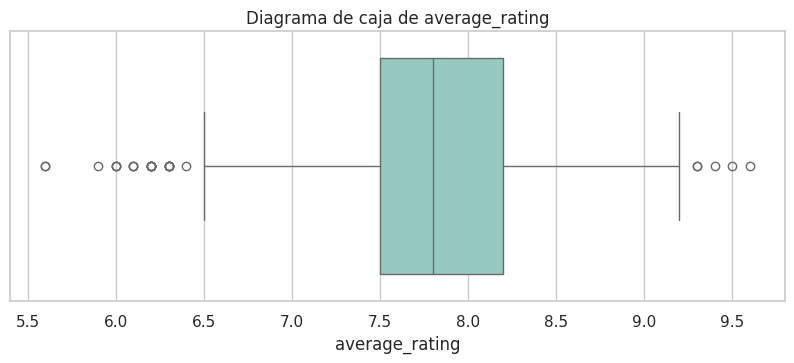

In [ ]:
plt.figure(figsize=(10, 3.5))
sns.boxplot(
x=df[columna_numerica],
color="#8ED1C6"
)
plt.title(f"Diagrama de caja de {columna_numerica}")
plt.xlabel(columna_numerica)
plt.show()

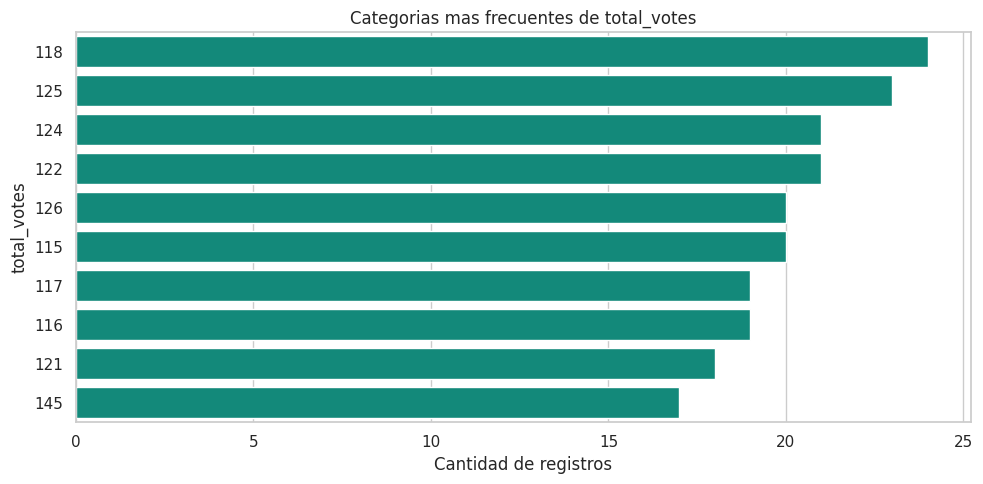

In [ ]:
top_categorias = df[columna_categorica].value_counts(
dropna=False
).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(
x=top_categorias.values,
y=top_categorias.index.astype(str),
color="#009C88"
)

plt.title(f"Categorias mas frecuentes de {columna_categorica}")
plt.xlabel("Cantidad de registros")
plt.ylabel(columna_categorica)
plt.tight_layout()
plt.show()


La categoría que domina es 118, alcanzando la frecuencia absoluta más alta con 24 registros.

Dentro de este top 10, las frecuencias están bastante equilibradas. No existe una categoría que sobrepase drásticamente al resto

Sí, omite una gran cantidad de categorías. Al sumar las frecuencias de las 10 barras visibles se obtienen solo 202 registros en total, el gráfico está omitiendo aproximadamente el 79 % de los datos restantes, los cuales corresponden a valores únicos de total_votes que tienen frecuencias aún menores

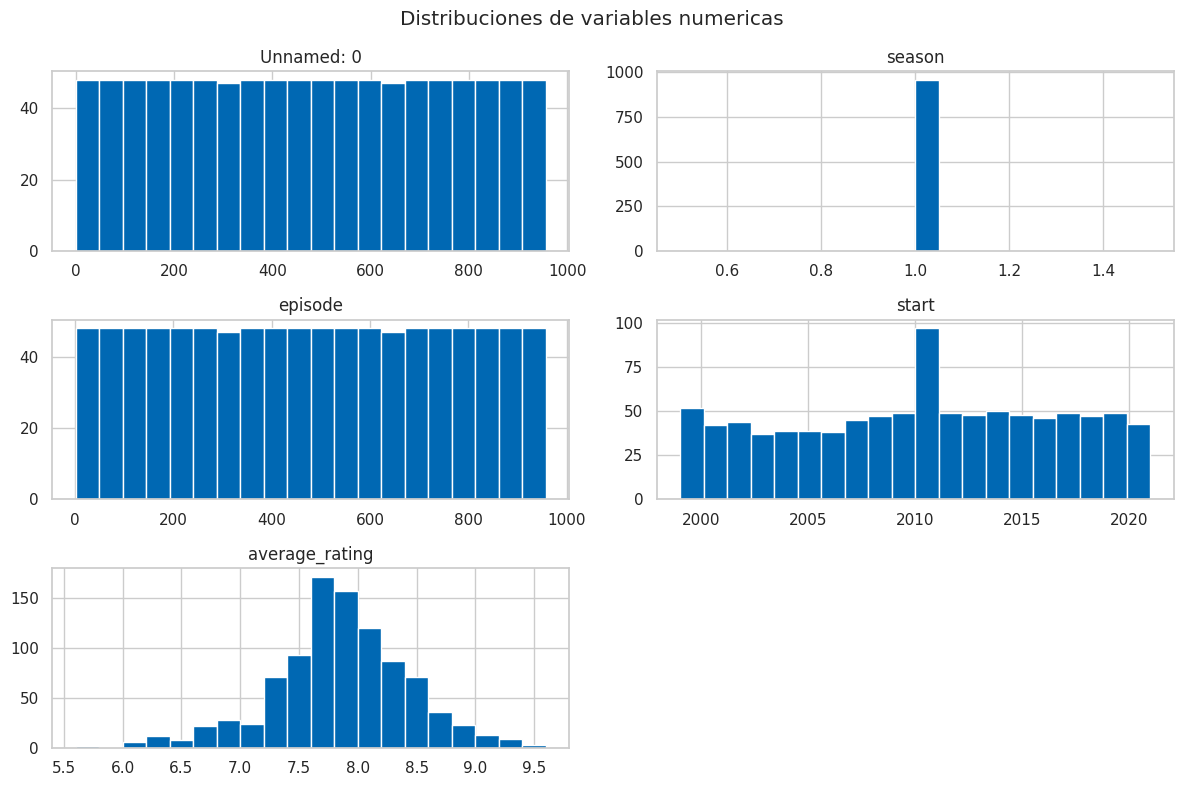

In [ ]:
seleccion_numericas = columnas_numericas[:6]
if seleccion_numericas:
  df[seleccion_numericas].hist(
  bins=20,
  figsize=(12, 8),
  color="#0068B3",
  edgecolor="white"
)
plt.suptitle("Distribuciones de variables numericas")
plt.tight_layout()
plt.show()

**Hallazgos Pricipales:**

**Hallazgo 1**: Concentración y simetría de la calificación promedio

Variable o aspecto: average_rating.

Resultado concreto: La media y la mediana coinciden exactamente en 7.80, con el 50 % central de los datos (entre el percentil 25 y el 75) ubicado entre 7.50 y 8.20.

Interpretación prudente: La distribución de las calificaciones es marcadamente simétrica y acampanada, lo que sugiere una recepción general positiva y homogénea por parte de la audiencia hacia la mayoría de los episodios.

Pregunta / Verificación pendiente: ¿La simetría se mantiene constante a lo largo de los años de emisión o existen temporadas específicas donde el promedio decae significativamente?

**Hallazgo 2**: Comportamiento en el extremo superior de las calificaciones

Variable o aspecto: average_rating (tramo superior y valores máximos).

Resultado concreto: Del percentil 95 (8.71) al valor máximo (9.60) existe una brecha de 0.89 puntos, superior a la amplitud de todo el rango intercuartil (0.70 puntos).

Interpretación prudente: Aunque son pocos registros, existe un grupo reducido de episodios considerados sobresalientes que se distancian de la tendencia habitual de la serie.

Pregunta / Verificación pendiente: ¿Cuáles son los episodios específicos que superan los 9.0 puntos y corresponden a hitos de la trama (finales de temporada, clímax, etc.)?

**Hallazgo 3: **Mínimo histórico en la evaluación de episodios

Variable o aspecto: average_rating (tramo inferior).

Resultado concreto: El valor mínimo registrado es de 5.60, mientras que el percentil 5 se sitúa en 6.70.

Interpretación prudente: Las calificaciones bajas son excepcionales en el dataset; la audiencia rara vez evalúa un episodio por debajo de 6.0, sugiriendo un piso de calidad percibida bastante alto o reticencia a puntajes reprobatorios.

Pregunta / Verificación pendiente: ¿Corresponden estos puntajes bajos a episodios de relleno (filler) o a problemas técnicos/narrativos particulares?

**Hallazgo 4:** Alta dispersión y cardinalidad en el volumen de votos

Variable o aspecto: total_votes.

Resultado concreto: La categoría más repetida es 118 votos con solo 24 registros, y las 10 frecuencias más altas suman apenas 202 observaciones de un total aproximado de 958.

Interpretación prudente: Tratar total_votes como una variable categórica no es analíticamente útil debido a su alta cardinalidad; cada valor individual representa un porcentaje marginal (cercano al 2 %) de los datos.

Pregunta / Verificación pendiente: ¿Es conveniente transformar esta variable a una escala continua o agruparla en rangos discretos (e.g., bajo, medio, alto volumen) para un análisis más claro?

**Hallazgo 5:** Estructura y evolución temporal de los episodios

Variable o aspecto: Variables temporales y de secuencia (start y episode).

Resultado concreto: Los registros abarcan desde el año 1999 (mínimo) hasta 2021 (máximo), sumando al menos 958 episodios secuenciales.

Interpretación prudente: La serie cuenta con una trayectoria de más de dos décadas de emisión ininterrumpida y un volumen masivo de producción regular.

Pregunta / Verificación pendiente: ¿Existen vacíos o interrupciones en la producción durante los 22 años observados?

**Hallazgo 6**: Invarianza en la codificación de la temporada

Variable o aspecto: season.

Resultado concreto: Desde el valor mínimo hasta el máximo (incluyendo todos los percentiles), el valor se mantiene constante en 1.00.

Interpretación prudente: La variable no presenta variabilidad en el dataset, funcionando más como una constante que como un factor explicativo o de segmentación.

Pregunta / Verificación pendiente: ¿Se trata de un formato de catalogación donde toda la serie fue registrada bajo una única temporada, o es un error en la extracción/limpieza original del dataset?

¿Para qué pregunta descriptiva podría servir este dataset?

Evolución histórica y temporal de la recepción: ¿Cómo ha evolucionado la calificación media (average_rating) y el volumen de participación (total_votes) de la serie a lo largo de sus 22 años de emisión (1999–2021) y más de 950 episodios?

Fortalezas observadas en el dataset

Cobertura longitudinal completa: Contiene un registro secuencial ininterrumpido de 958 episodios que cubre desde el estreno en 1999 hasta 2021, permitiendo análisis de series temporales y tendencias a largo plazo.

Problemas o dudas que deben investigarse antes de construir un modelo

Discrepancia y suciedad en tipos de datos (dtypes):

total_votes y rank están almacenados como texto (object) por contener separadores de miles (comas). Deben limpiarse y convertirse a enteros.

trend contiene guiones ("-") para representar la ausencia de cambio, lo que forzó su lectura como texto en vez de numérica.



El trabajo desarrollado en este laboratorio corresponde principalmente a la fase de Comprensión de los Datos (Data Understanding) de la metodología CRISP-DM.

Esta correspondencia se fundamenta de forma concreta en el conjunto de actividades exploratorias y analíticas ejecutadas a lo largo de la práctica: